In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ulnnproject/machinelearning/machine learning.mp4


In [4]:
!pip install torch
!pip install whisper
!pip uninstall -y whisper
!pip uninstall -y openai-whisper
!pip install openai-whisper

  Using cached whisper-1.1.10-py3-none-any.whl
Found existing installation: whisper 1.1.10
Uninstalling whisper-1.1.10:
  Successfully uninstalled whisper-1.1.10
Found existing installation: openai-whisper 20250625
Uninstalling openai-whisper-20250625:
  Successfully uninstalled openai-whisper-20250625
  Using cached openai_whisper-20250625-py3-none-any.whl


In [5]:
import torch
import whisper
import subprocess
import json
import re
import os
import matplotlib.pyplot as plt
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [6]:
VIDEO_PATH = "/kaggle/input/datasets/ulnnproject/machinelearning/machine learning.mp4"

AUDIO_PATH = "audio.wav"

LLM_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"

SAVE_PATH = "/kaggle/working/saved_models"

os.makedirs(SAVE_PATH, exist_ok=True)

print("✅ Save folder created:", SAVE_PATH)

✅ Save folder created: /kaggle/working/saved_models


In [7]:
print("🔄 Loading LLM...")

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)

llm_pipeline = pipeline(
    "text-generation",
    model=LLM_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    tokenizer=tokenizer
)

print("✅ LLM Loaded Successfully")

🔄 Loading LLM...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ LLM Loaded Successfully


In [8]:
tokenizer.save_pretrained(
    f"{SAVE_PATH}/tokenizer"
)

print("✅ Tokenizer Saved Successfully")

✅ Tokenizer Saved Successfully


In [9]:
def extract_audio(video_path, audio_path):
    command = [
        "ffmpeg",
        "-i", video_path,
        "-ar", "16000",
        "-ac", "1",
        "-y",
        audio_path
    ]

    subprocess.run(command, check=True)
    return audio_path

In [10]:
def transcribe_audio(audio_path):
    model_whisper = whisper.load_model("base")

    result = model_whisper.transcribe(audio_path)

    return result["segments"], model_whisper

In [11]:
def transcribe_audio(audio_path):
    model_whisper = whisper.load_model("base")

    result = model_whisper.transcribe(audio_path)

    return result["segments"], model_whisper

In [12]:
def save_whisper_model(model):

    torch.save(
        model.state_dict(),
        f"{SAVE_PATH}/whisper_base_model.pth"
    )

    print("✅ Whisper Model Saved Successfully")

In [13]:
def get_full_transcript(segments):
    return " ".join([
        seg["text"].strip()
        for seg in segments
    ])

In [14]:
def call_llm(prompt, max_retries=2):

    for attempt in range(max_retries):
        try:
            output = llm_pipeline(
                prompt,
                max_new_tokens=1024,
                do_sample=True,
                temperature=0.4,
                return_full_text=False
            )

            return output[0]["generated_text"]

        except Exception as e:
            print(f"⚠️ LLM error (attempt {attempt+1}): {e}")

    return ""

In [15]:
def extract_concepts_and_mcqs(transcript):

    truncated = transcript[:3000]

    prompt = f"""
<s>[INST]

You are an AI tutor.

From the transcript below:

1. Identify 3 to 5 key learning concepts
2. For EACH concept, write ONE multiple choice question
3. Each MCQ must have exactly 4 options

IMPORTANT:
Return ONLY valid JSON array

Example:

[
  {{
    "title": "Concept Name",
    "question": "What is...?",
    "options": [
      "A. option1",
      "B. option2",
      "C. option3",
      "D. option4"
    ],
    "answer": "A"
  }}
]

Transcript:
{truncated}

[/INST]
"""

    response = call_llm(prompt)

    try:
        match = re.search(r'\[.*\]', response, re.DOTALL)

        if match:
            data = json.loads(match.group())

            validated = []

            for item in data:
                if all(
                    k in item
                    for k in [
                        "title",
                        "question",
                        "options",
                        "answer"
                    ]
                ):
                    if len(item["options"]) == 4:
                        validated.append(item)

            return validated

    except json.JSONDecodeError as e:
        print(f"⚠️ JSON parse error: {e}")

    return []

In [16]:
def save_mcqs(mcqs):

    with open(
        f"{SAVE_PATH}/generated_mcqs.json",
        "w"
    ) as file:

        json.dump(
            mcqs,
            file,
            indent=4
        )

    print("✅ MCQs Saved Successfully")

In [17]:
def map_to_timestamps(concepts, segments, total_duration=None):

    if total_duration is None:
        total_duration = segments[-1]["end"] if segments else 60

    mapped = []
    n = len(concepts)

    for i, concept in enumerate(concepts):

        title_words = set(
            concept["title"].lower().split()
        )

        best_seg = None

        for seg in segments:

            seg_words = set(
                seg["text"].lower().split()
            )

            overlap = [
                w for w in title_words
                if len(w) > 3 and w in seg_words
            ]

            if overlap:
                best_seg = seg
                break

        if best_seg:
            mapped.append({
                "concept": concept,
                "start": best_seg["start"],
                "end": best_seg["end"]
            })

        else:
            mapped.append({
                "concept": concept,
                "start": (i / n) * total_duration,
                "end": ((i + 1) / n) * total_duration
            })

    mapped.sort(
        key=lambda x: x["start"]
    )

    return mapped

In [18]:
def save_mapping(mapped):

    with open(
        f"{SAVE_PATH}/concept_mapping.json",
        "w"
    ) as file:

        json.dump(
            mapped,
            file,
            indent=4
        )

    print("✅ Concept Mapping Saved Successfully")

In [19]:
def generate_new_question(concept_title, transcript):

    prompt = f"""
<s>[INST]

You are an AI tutor.

Generate ONE NEW multiple choice question for this concept:

Concept: {concept_title}

Context:
{transcript[:2000]}

Rules:
1. Different from previous question
2. Exactly 4 options
3. Return ONLY valid JSON

Format:

{{
    "question": "Question here?",
    "options": [
        "A. option1",
        "B. option2",
        "C. option3",
        "D. option4"
    ],
    "answer": "A"
}}

[/INST]
"""

    response = call_llm(prompt)

    try:
        match = re.search(r"\{.*\}", response, re.DOTALL)

        if match:
            new_q = json.loads(match.group())

            if all(
                k in new_q
                for k in ["question", "options", "answer"]
            ):
                return new_q

    except Exception as e:
        print("⚠️ New Question Generation Error:", e)

    return None

In [20]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()

    labels = ["Wrong", "Correct"]
    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

In [21]:
def save_evaluation_results(y_true, y_pred):

    results = {
        "Accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "Precision": float(
            precision_score(
                y_true,
                y_pred,
                average="binary"
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                y_pred,
                average="binary"
            )
        ),
        "F1 Score": float(
            f1_score(
                y_true,
                y_pred,
                average="binary"
            )
        ),
        "Confusion Matrix": confusion_matrix(
            y_true,
            y_pred
        ).tolist()
    }

    with open(
        f"{SAVE_PATH}/evaluation_results.json",
        "w"
    ) as file:

        json.dump(
            results,
            file,
            indent=4
        )

    print("✅ Evaluation Results Saved Successfully")

In [22]:
def evaluate_results(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="binary")
    rec = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    print("\n" + "="*50)
    print("📊 PERFORMANCE EVALUATION")
    print("="*50)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    plot_confusion_matrix(y_true, y_pred)

    save_evaluation_results(y_true, y_pred)

In [23]:
def run_learning(video_path):

    print("🔊 Extracting audio...")
    audio = extract_audio(video_path, AUDIO_PATH)

    print("📝 Transcribing...")
    segments, whisper_model = transcribe_audio(audio)

    save_whisper_model(whisper_model)

    print("🧠 Building transcript...")
    transcript = get_full_transcript(segments)

    print("🤖 Generating concepts + MCQs...")
    concepts = extract_concepts_and_mcqs(transcript)

    if not concepts:
        print("❌ Failed to generate concepts.")
        return

    save_mcqs(concepts)

    total_duration = segments[-1]["end"]

    mapped = map_to_timestamps(
        concepts,
        segments,
        total_duration
    )

    save_mapping(mapped)

    print(f"✅ {len(mapped)} concepts mapped\n")

    y_true = []
    y_pred = []

    idx = 0

    while idx < len(mapped):

        item = mapped[idx]
        concept = item["concept"]

        print("\n" + "="*40)
        print(f"▶ Segment: {item['start']:.1f}s → {item['end']:.1f}s")
        print(f"📘 Concept: {concept['title']}")
        print("⏸ Video paused for quiz")

        print(f"\n❓ {concept['question']}")

        for opt in concept["options"]:
            print(opt)

        user_ans = input(
            "\nYour answer (A/B/C/D): "
        ).strip().upper()

        correct_ans = concept["answer"].upper()

        y_true.append(1)

        if user_ans == correct_ans:
            print("✅ Correct! Moving forward...")
            y_pred.append(1)
            idx += 1

        else:
            print(f"❌ Wrong! Correct Answer: {correct_ans}")
            y_pred.append(0)

            print("🔁 Replaying SAME concept...")
            print("⏪ Video replay starts from THIS concept")

            print("🤖 Generating NEW question...")

            new_question = generate_new_question(
                concept["title"],
                transcript
            )

            if new_question:
                concept["question"] = new_question["question"]
                concept["options"] = new_question["options"]
                concept["answer"] = new_question["answer"]

                print("✅ New question generated")

            else:
                print("⚠️ Using old question again")

    evaluate_results(y_true, y_pred)

    print("\n🎉 Learning Complete!")

🔊 Extracting audio...


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

📝 Transcribing...



  0%|                                               | 0.00/139M [00:00<?, ?iB/s]
  7%|██▊                                    | 9.86M/139M [00:00<00:01, 103MiB/s]
 20%|███████▋                               | 27.1M/139M [00:00<00:00, 149MiB/s]
 31%|███████████▉                           | 42.4M/139M [00:00<00:00, 154MiB/s]
 41%|████████████████▏                      | 57.4M/139M [00:00<00:00, 155MiB/s]
 54%|█████████████████████▏                 | 75.4M/139M [00:00<00:00, 168MiB/s]
 67%|█████████████████████████▉             | 92.3M/139M [00:00<00:00, 170MiB/s]
 78%|███████████████████████████████▎        | 109M/139M [00:00<00:00, 163MiB/s]
100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 158MiB/s]
Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not

✅ Whisper Model Saved Successfully
🧠 Building transcript...
🤖 Generating concepts + MCQs...
✅ MCQs Saved Successfully
✅ Concept Mapping Saved Successfully
✅ 3 concepts mapped


▶ Segment: 0.0s → 6.7s
📘 Concept: Classification Problem
⏸ Video paused for quiz

❓ Which type of problem is logistic regression used to solve?
A. Linear problems
B. Continuous prediction problems
C. Categorical prediction problems
D. Time series problems


...


Your answer (A/B/C/D):  B


✅ Correct! Moving forward...

▶ Segment: 0.0s → 6.7s
📘 Concept: Logistic Regression vs Linear Regression
⏸ Video paused for quiz

❓ What is the main difference between logistic regression and linear regression?
A. Linear regression is used for categorical prediction problems
B. Logistic regression is used for continuous prediction problems
C. Logistic regression uses a linear equation line but outputs a probability
D. Linear regression uses a logistic function to output a probability



Your answer (A/B/C/D):  C


✅ Correct! Moving forward...

📊 PERFORMANCE EVALUATION
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


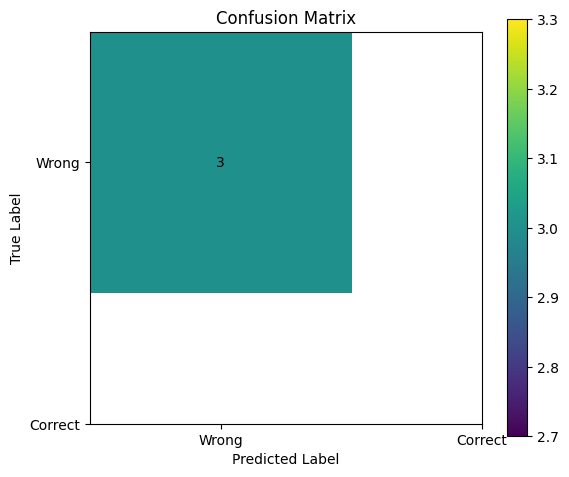

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


✅ Evaluation Results Saved Successfully

🎉 Learning Complete!


In [24]:
run_learning(VIDEO_PATH)

In [25]:
# Step 21 — Zip All Output Files for Download

import shutil

SOURCE_FOLDER = "/kaggle/working/saved_models"
ZIP_FILE_NAME = "/kaggle/working/project_outputs"

shutil.make_archive(
    ZIP_FILE_NAME,
    'zip',
    SOURCE_FOLDER
)

print("✅ ZIP file created successfully!")
print("📁 File Location: /kaggle/working/project_outputs.zip")

✅ ZIP file created successfully!
📁 File Location: /kaggle/working/project_outputs.zip
